Прогнозирование одобрения кредитных карт
---
**Цель проекта:** Построение модели машинного обучения для автоматизации процесса кредитного скоринга.
**Основные задачи:**
* Анализ и предобработка данных с сильным дисбалансом классов.
* Обработка аномалий и генерация новых признаков.
* Сравнение линейных (Logistic Regression) и ансамблевых (Random Forest) моделей для минимизации банковских рисков.

---
Импорт библиотек

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set(style="whitegrid")

1. Загрузка и первичная очистка

In [6]:
df.head(5)

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [7]:
df = pd.read_csv('Credit_card.csv')

# Исправление аномалии в стаже
# В этом датасете 365243 означает отсутствие работы (пенсионеры/безработные)
df.loc[df['Employed_days'] > 0, 'Employed_days'] = 0

# Birthday_count и Employed_days идут со знаком минус
df['Age'] = -(df['Birthday_count'] // 365)
df['Years_Experience'] = -(df['Employed_days'] // 365)

# Удаляем старые столбцы, ID и неинформативные признаки
cols_to_drop = ['Ind_ID', 'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID']
df.drop(columns=cols_to_drop, inplace=True)

# Заполняем Annual_income медианой, Type_Occupation заглушкой
df['Annual_income'] = df['Annual_income'].fillna(df['Annual_income'].median())
df['Type_Occupation'] = df['Type_Occupation'].fillna('Other')
# Для остальных (если есть NaN в Birthday_count) — удаляем строки, их обычно мало
df.dropna(inplace=True)

2. Подготовка данных к обучению

In [8]:
# Превращаем категории в числа (One-Hot Encoding)
df_final = pd.get_dummies(df, drop_first=True)

X = df_final.drop('label', axis=1)
y = df_final['label']

# Разделяем на train/test со стратификацией по label
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование (критично для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

3. Моделирование (Сравнение)

In [9]:
# --- Модель 1: Logistic Regression (Baseline) ---
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# --- Модель 2: Random Forest (Final Model) ---
# Для леса масштабирование не обязательно, используем исходные данные
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))
print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       270
           1       0.16      0.47      0.23        34

    accuracy                           0.65       304
   macro avg       0.53      0.57      0.51       304
weighted avg       0.83      0.65      0.72       304


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       270
           1       0.71      0.29      0.42        34

    accuracy                           0.91       304
   macro avg       0.82      0.64      0.68       304
weighted avg       0.89      0.91      0.89       304



4. Визуализация результатов

Логистическая регрессия (слева) слишком часто одобряет карты «всем подряд».
Случайный Лес (справа) работает гораздо точнее, минимизируя риски банка.

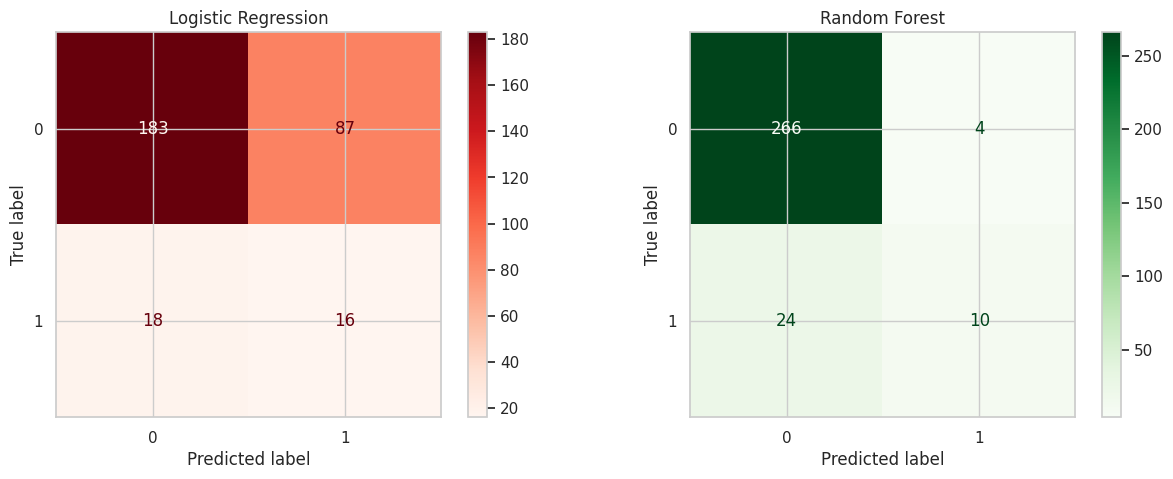

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Reds', ax=ax[0])
ax[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest')

plt.show()

---
# Итоговый вывод
1. **Линейные модели (Logistic Regression):** Не справляются с данным набором
признаков из-за нелинейных зависимостей в данных. При попытке найти значимую долю клиентов (`Recall 0.47`) точность (`Precision`) падает до `0.16`. Это означает, что `84%` одобренных заявок будут ошибочными, что неприемлемо для банковских рисков.

2. **Random Forest:** Показал лучший результат. Модель достигла точности `0.71` (`Precision`), что позволяет банку быть уверенным в надежности большинства одобряемых заемщиков. Общая точность системы (`Accuracy`) составила `91%`.

3. **Работа с дисбалансом:** Использование встроенных весов классов (`class_weight='balanced_subsample'`) позволило эффективно обучить модель на несбалансированной выборке, обеспечив высокую точность классификации без искажения исходных данных.